# Advanced Search - Larger cover Smaller method


## Load Models


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# load the pipelined model
import os
import joblib
from utils.FixedLengthTransformer import FixedLengthTransformer
# load the saved models from the Models directory
model_dir = "Models"
model_files = [f for f in os.listdir(model_dir) if f.endswith('.joblib')]
models = {}
for model_file in model_files:
    model_name = model_file.split('.')[0]
    models[model_name] = joblib.load(os.path.join(model_dir, model_file))
    
# print the model names
print("Available models:")
for model_name in models.keys():
    print(model_name)

selected_models_for_adv = ['Width Aug OHLC_mini_rocket_xgb','Length Normed + Width Aug OHLC_mini_rocket_xgb']
# selected_models_for_adv = ['Width Aug OHLC_mini_rocket_xgb']

Available models:
Width Aug OHLC + traindata Aug_mini_rocket_xgb
Width Aug OHLC_rocket_xgb
Width Aug OHLC_mini_rocket_xgb
Width Aug OHLC + traindata Aug_rocket_xgb
Length Normed + Width Aug OHLC_rocket_xgb
Plane OHLC + traindata Aug_mini_rocket_xgb
Width Aug OHLC + traindata Aug_multi_rocket_xgb
Width Aug OHLC_multi_rocket_xgb
Plane OHLC_rocket_xgb
Plane OHLC + traindata Aug_rocket_xgb
Plane OHLC_mini_rocket_xgb
Plane OHLC_multi_rocket_xgb
Length Normed + Width Aug OHLC_mini_rocket_xgb
Plane OHLC + traindata Aug_multi_rocket_xgb
Length Normed + Width Aug OHLC_multi_rocket_xgb
Length Normed OHLC_multi_rocket_xgb
Length Normed OHLC_mini_rocket_xgb
Length Normed OHLC_rocket_xgb


## Selecting the test sample


In [5]:
import random
random.seed(69)

test_pattern_segment_wise = pd.read_csv("Datasets/New_pattern_set_data/test_patterns_large_segment_wise.csv")
# convert Seg_Start , Seg_End , Start and End to datetime
test_pattern_segment_wise.loc[:, 'Seg_Start'] = pd.to_datetime(test_pattern_segment_wise['Seg_Start'])
test_pattern_segment_wise.loc[:, 'Seg_End'] = pd.to_datetime(test_pattern_segment_wise['Seg_End'])
test_pattern_segment_wise.loc[:, 'Start'] = pd.to_datetime(test_pattern_segment_wise['Start'])
test_pattern_segment_wise.loc[:, 'End'] = pd.to_datetime(test_pattern_segment_wise['End'])

# only have the rows with start_date = '2019-01-01' start date higher than this
test_pattern_segment_wise = test_pattern_segment_wise[test_pattern_segment_wise['Start'] > pd.to_datetime('2019-01-01')]

test_seg_ids_adv = test_pattern_segment_wise['Seg_ID'].unique()
# select random 100 seg ids from the test_seg_ids_adv
test_seg_ids_adv = random.sample(list(test_seg_ids_adv), 100)

selected_test_pattern_segment_wise_adv = test_pattern_segment_wise[test_pattern_segment_wise['Seg_ID'].isin(test_seg_ids_adv)]
# selected_test_pattern_segment_wise_adv = test_pattern_segment_wise.copy()

test_ids_rows_count_sum_adv = test_pattern_segment_wise[test_pattern_segment_wise['Seg_ID'].isin(test_seg_ids_adv)].groupby('Seg_ID').size().sum()
test_ids_rows_count_sum_adv , len(test_seg_ids_adv)

(np.int64(116), 100)

## Advance pattern Locating


In [6]:
# window_size = 20
# win_size_proportion = 5
win_size_proportions = np.round(np.logspace(0, np.log10(20), num=10), 2).tolist()
# Example output: [1.0, 1.58, 2.5, 3.95, 6.25, 9.88, 15.63, 20.0]
padding_proportion = 0.6
stride = 1
probability_threshold = 0.4
# for len norm 
target_len = 30

eps=0.04 # in the dbscan clustering
min_samples=3 # in the dbscan clustering
win_width_proportion=10 # in the dbscan clustering from what amount to divide the width related feature


/home/uomai/Candlestick-Chart-Pattern-Detection-FYP/utils/patternLocating.py:213: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  group['Seg_Start'] = pd.to_datetime(group['Seg_Start'])
/home/uomai/Candlestick-Chart-Pattern-Detection-FYP/utils/patternLocating.py:214: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  group['Seg_End'] = pd.to_datetime(group['Seg_End'])


Pattern Name :  Triangle, symmetrical Pattern Start :  2024-08-16 00:00:00 Pattern End :  2024-09-05 00:00:00


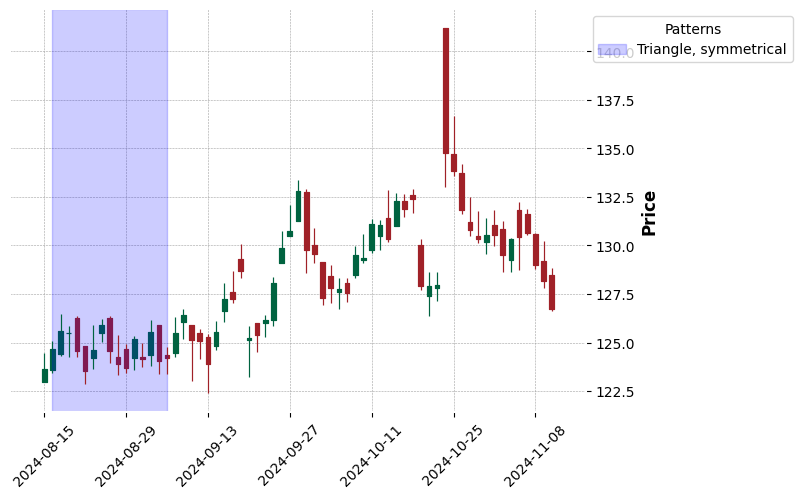

/home/uomai/Candlestick-Chart-Pattern-Detection-FYP/utils/patternLocating.py:213: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  group['Seg_Start'] = pd.to_datetime(group['Seg_Start'])
/home/uomai/Candlestick-Chart-Pattern-Detection-FYP/utils/patternLocating.py:214: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  group['Seg_End'] = pd.to_datetime(group['Seg_End'])


Pattern Name :  Double Bottom Pattern Start :  2022-06-16 00:00:00 Pattern End :  2022-06-30 00:00:00


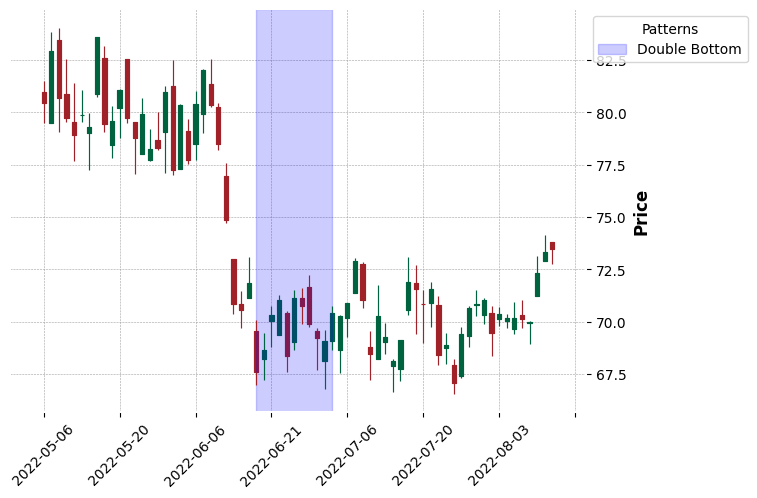

/home/uomai/Candlestick-Chart-Pattern-Detection-FYP/utils/patternLocating.py:213: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  group['Seg_Start'] = pd.to_datetime(group['Seg_Start'])
/home/uomai/Candlestick-Chart-Pattern-Detection-FYP/utils/patternLocating.py:214: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  group['Seg_End'] = pd.to_datetime(group['Seg_End'])


Pattern Name :  Double Bottom Pattern Start :  2025-01-27 00:00:00 Pattern End :  2025-02-03 00:00:00


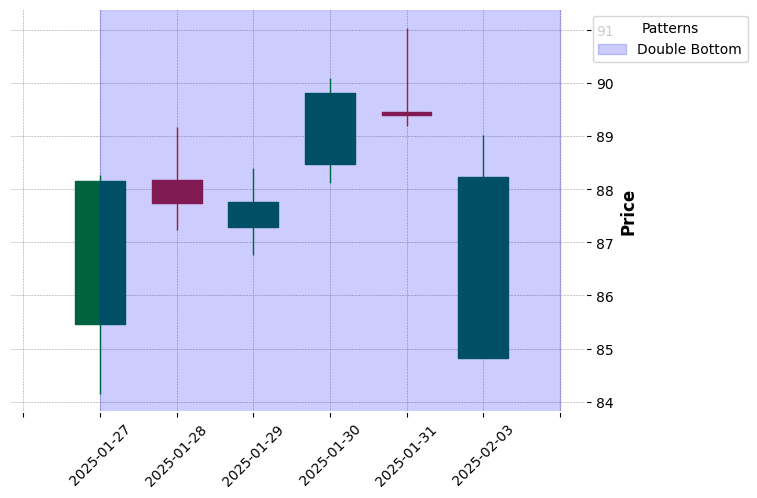

Pattern Name : 

/home/uomai/Candlestick-Chart-Pattern-Detection-FYP/utils/patternLocating.py:213: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  group['Seg_Start'] = pd.to_datetime(group['Seg_Start'])
/home/uomai/Candlestick-Chart-Pattern-Detection-FYP/utils/patternLocating.py:214: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  group['Seg_End'] = pd.to_datetime(group['Seg_End'])


 Double Bottom Pattern Start :  2022-07-06 00:00:00 Pattern End :  2022-07-14 00:00:00
Pattern Name :  Head-and-shoulders top Pattern Start :  2022-08-12 00:00:00 Pattern End :  2022-09-12 00:00:00


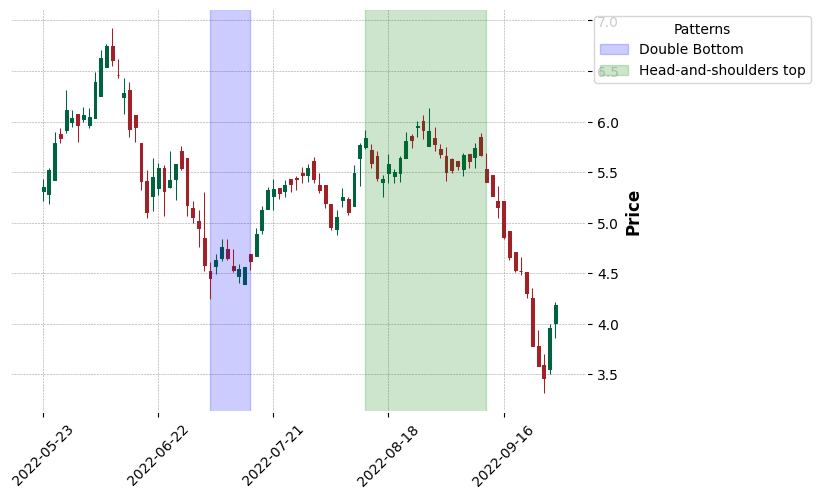

In [7]:
from utils.patternLocating import plot_patterns_for_segment

plot_count1 = 4

for id in test_seg_ids_adv:
    if plot_count1 >0:
        test_seg_id = id
        plot_patterns_for_segment(test_seg_id , test_pattern_segment_wise)
        plot_count1 -= 1

In [8]:
test_seg_id

np.int64(452)

Selected model: Width Aug OHLC_mini_rocket_xgb


Processing test segments:   0%|          | 0/100 [00:00<?, ?it/s][Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:   12.3s
[Parallel(n_jobs=16)]: Done  63 out of  63 | elapsed:   16.3s finished
[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    2.4s
[Parallel(n_jobs=16)]: Done  63 out of  63 | elapsed:    5.7s finished
[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    2.4s
[Parallel(n_jobs=16)]: Done  63 out of  63 | elapsed:    5.6s finished
[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    2.0s
[Parallel(n_jobs=16)]: Done  63 out of  63 | elapsed:    5.4s finished
[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=1

Double Bottom  :
    Clustered Windows :


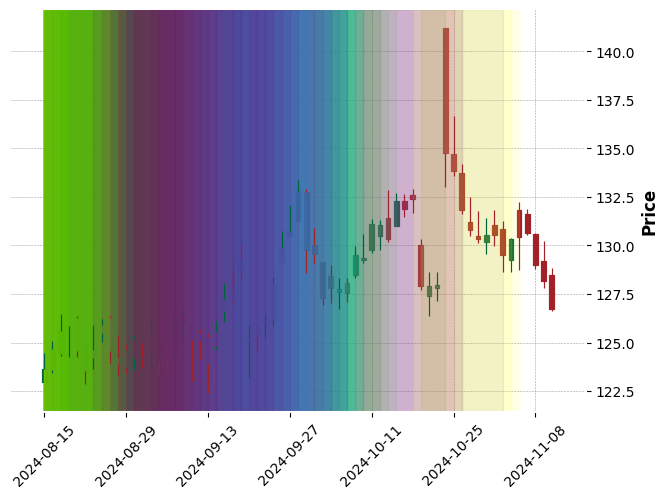

    Finalized Section :


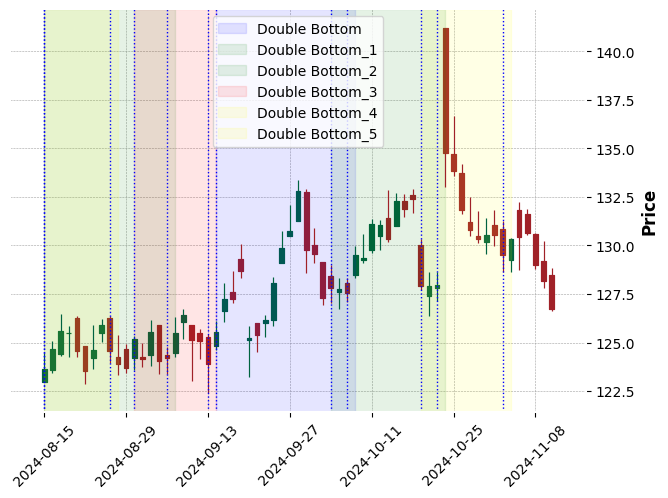

Double Top  :
    Clustered Windows :


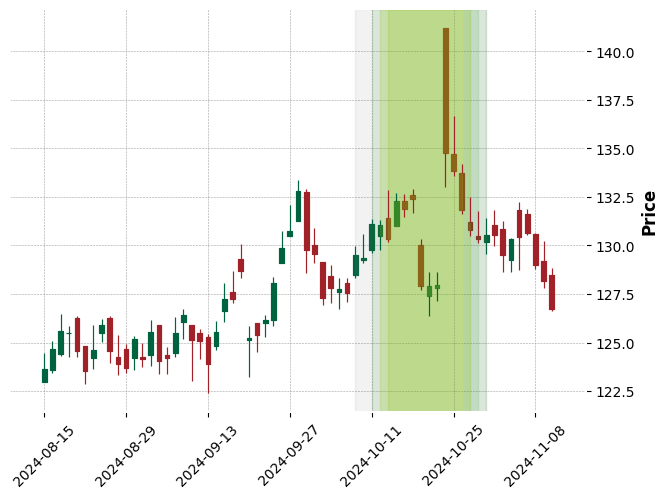

    Finalized Section :


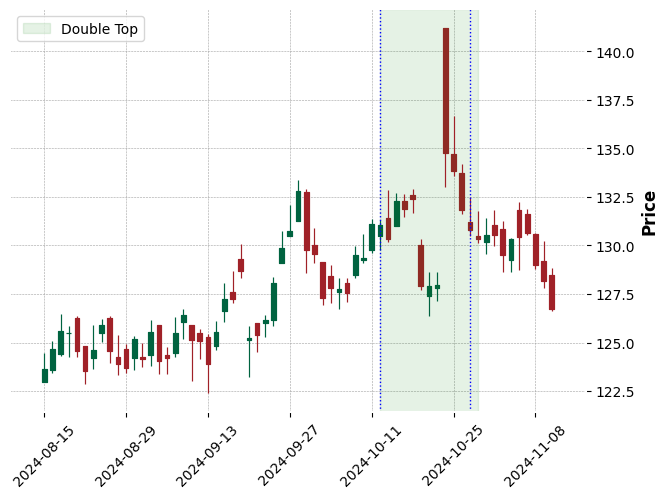

Flag, high and tight  :
    Clustered Windows :


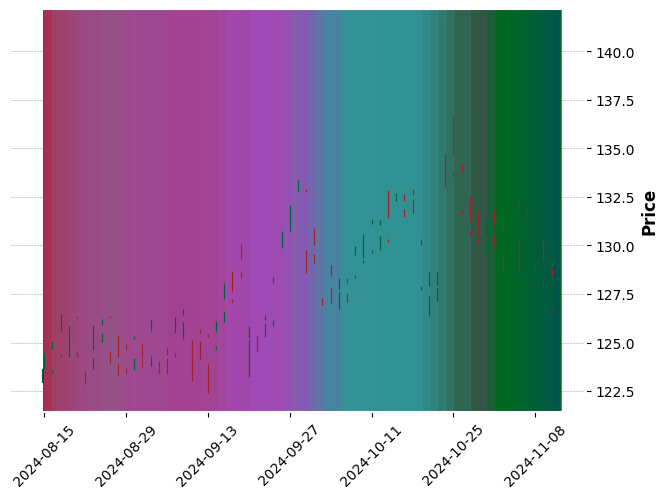

    Finalized Section :


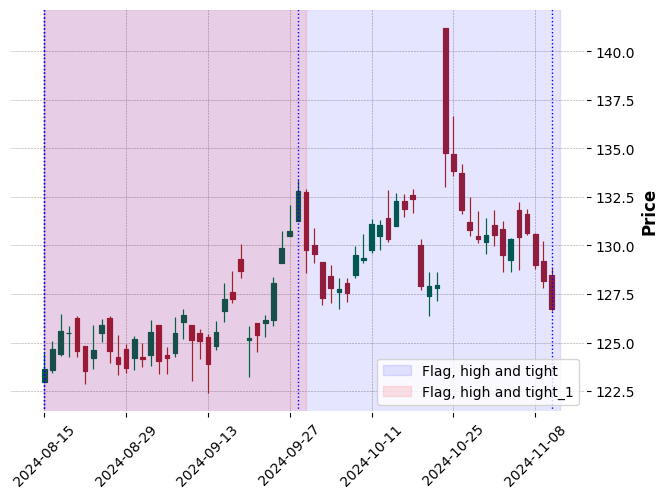

Head-and-shoulders top  :
    Clustered Windows :


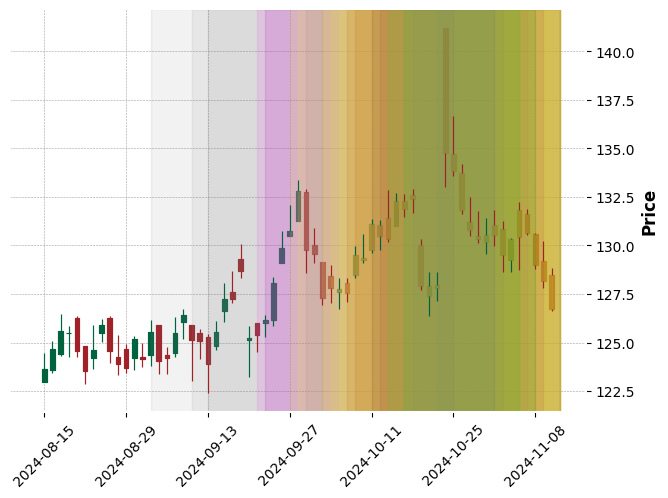

    Finalized Section :


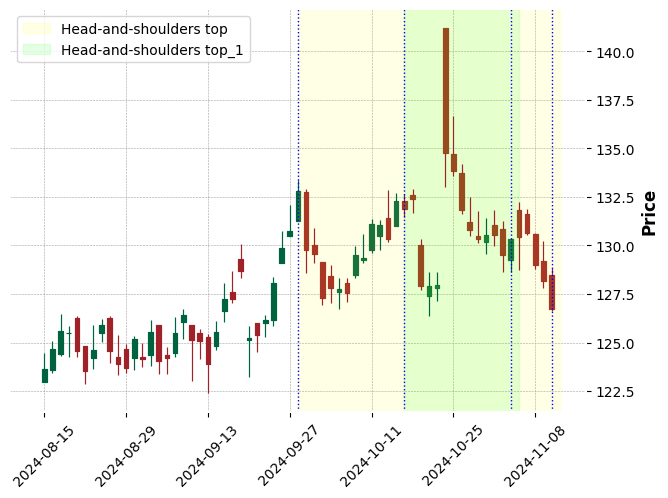

No Pattern  :
    Clustered Windows :


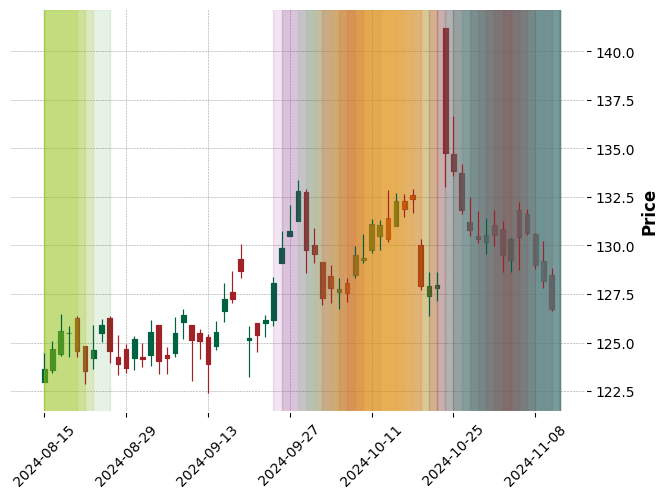

    Finalized Section :


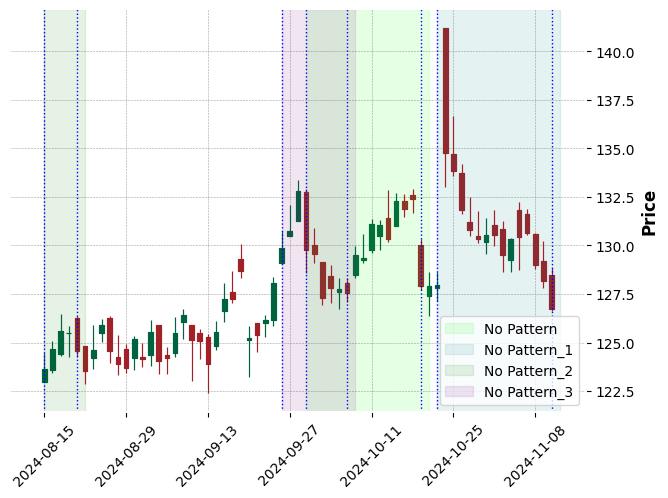

Triangle, symmetrical  :
    Clustered Windows :


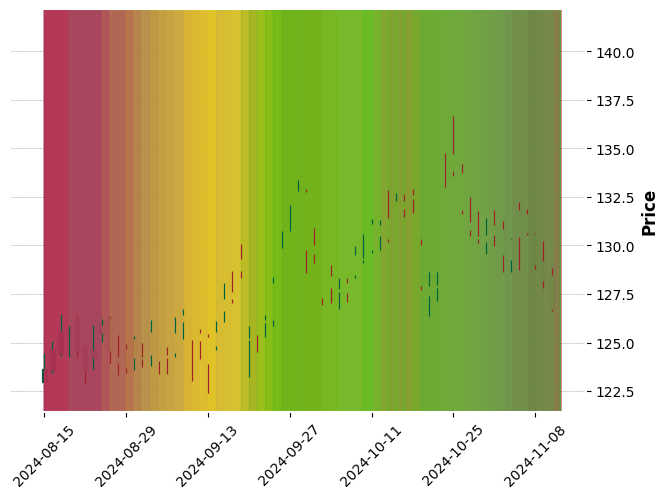

    Finalized Section :


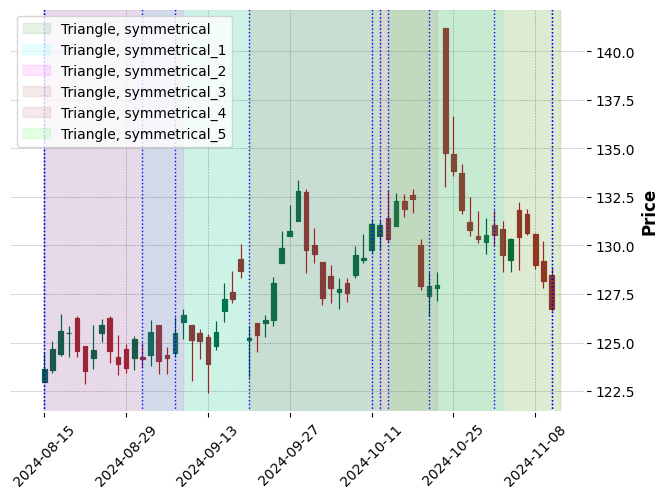

Processing test segments:   1%|          | 1/100 [01:03<1:44:40, 63.44s/it][Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    2.1s
[Parallel(n_jobs=16)]: Done  68 out of  68 | elapsed:    5.8s finished
[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    2.4s
[Parallel(n_jobs=16)]: Done  68 out of  68 | elapsed:    6.0s finished
[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    2.5s
[Parallel(n_jobs=16)]: Done  68 out of  68 | elapsed:    6.3s finished
[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    2.4s
[Parallel(n_jobs=16)]: Done  68 out of  68 | elapsed:    6.8s finished
[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Paralle

In [10]:
import sys

from tqdm import tqdm

from utils.formatAndPreprocessNewPatterns import get_reverse_pattern_encoding
from utils.functionalPatternLocateAndPlot import functional_pattern_filter_and_point_recognition
from utils.patternLocating import  get_ohlc_data_segment, parallel_process_sliding_window, prepare_dataset_for_cluster
from utils.functionalPatternLocateAndPlot import plot_pattern_groups_and_finalized_sections
from utils.patternLocating import cluster_windows
from utils.eval import intersection_over_union

located_patterns_and_other_info_dict = {}
window_results_dict = {}
pattern_encoding_reversed = get_reverse_pattern_encoding()
path = 'Datasets/OHLC data'
data_dir = "Datasets/New_pattern_set_data/Adv_Method3_init/"

plot_count = 2

for model_name in selected_models_for_adv:
    print(f"Selected model: {model_name}")
    model = models[model_name]
    
    located_patterns_and_other_info_list = []
    window_results_list = []

    # for seg_id, group in tqdm(grouped, desc="Processing segments"):
        
    #     test_seg_id = seg_id  
    for test_seg_id in tqdm(test_seg_ids_adv, desc="Processing test segments"):
        # try :
            # plot_patterns_for_segment(test_seg_id    , test_pattern_segment_wise)
            grouped = test_pattern_segment_wise.groupby('Seg_ID')
            # Select a group
            group = grouped.get_group(test_seg_id)

            Seg_Start = group.iloc[0]['Seg_Start']
            Seg_End = group.iloc[0]['Seg_End']
            seg_len = (Seg_End - Seg_Start).days
            
            win_results_for_each_size = []
            located_patterns_and_other_info_for_each_size = []
            cluster_labled_windows_list = []
            
            used_win_sizes = []
            win_iteration = 0
            
            for win_size_proportion in win_size_proportions:

                window_size = seg_len // win_size_proportion
                # print(f"Win size : {window_size}")
                if window_size < 10:
                    window_size = 10
                # elif window_size > 30:
                #     window_size = 30
                    
                # convert to int 
                window_size = int(window_size)
                if window_size in used_win_sizes:
                    continue
                used_win_sizes.append(window_size)
                
                    
                ohlc_data_segment = get_ohlc_data_segment(test_pattern_segment_wise, test_seg_id, path,group) 
                if ohlc_data_segment is None or len(ohlc_data_segment) == 0:
                    print("OHLC Data segment is empty")
                    continue   
                
                len_norm=False
                target_len = target_len
                
                # geet th efirst two words of the model_name 
                model_name_parts = model_name.split(' ')
                data_set_type = model_name_parts[0] + ' ' + model_name_parts[1]
                data_set_type
                
                if data_set_type == "Length Normed":
                    len_norm=True
                
                win_results_df = parallel_process_sliding_window(ohlc_data_segment, model, probability_threshold,stride, pattern_encoding_reversed,group,test_seg_id,window_size, padding_proportion, len_norm, target_len)
                
                if win_results_df is None or len(win_results_df) == 0:
                    print("Window results dataframe is empty")
                    continue
                win_results_df['Window_Size'] = window_size
                win_results_for_each_size.append(win_results_df)
                # plot_sliding_steps(win_results_df ,ohlc_data_segment,probability_threshold ,test_seg_id)
                predicted_patterns = prepare_dataset_for_cluster(ohlc_data_segment, win_results_df)
                if predicted_patterns is None or len(predicted_patterns) == 0:
                    print("Predicted patterns dataframe is empty")
                # print("Predicted Patterns :",predicted_patterns)
                cluster_labled_windows_df , interseced_clusters_df = cluster_windows(predicted_patterns, probability_threshold, window_size)
                if cluster_labled_windows_df is None or interseced_clusters_df is None or len(cluster_labled_windows_df) == 0 or len(interseced_clusters_df) == 0:
                    print("Clustered windows dataframe is empty")
                    continue
                mask = cluster_labled_windows_df['Cluster'] != -1
                cluster_labled_windows_df.loc[mask, 'Cluster'] = cluster_labled_windows_df.loc[mask, 'Cluster'].astype(int) + win_iteration
                # mask2 = interseced_clusters_df['Cluster'] != -1
                interseced_clusters_df['Cluster'] = interseced_clusters_df['Cluster'].astype(int) + win_iteration
                num_of_unique_clusters = interseced_clusters_df[interseced_clusters_df['Cluster']!=-1]['Cluster'].nunique()
                win_iteration += num_of_unique_clusters 
                cluster_labled_windows_list.append(cluster_labled_windows_df)
                located_patterns_and_other_info = functional_pattern_filter_and_point_recognition(interseced_clusters_df)
                if located_patterns_and_other_info is None or len(located_patterns_and_other_info) == 0:
                    print("Located patterns and other info dataframe is empty")
                    continue
                # plot_pattern_groups_and_finalized_sections(located_patterns_and_other_info, cluster_labled_windows_df, test_seg_id)
                located_patterns_and_other_info['Window_Size'] = window_size
                
                located_patterns_and_other_info_for_each_size.append(located_patterns_and_other_info)
                
            if located_patterns_and_other_info_for_each_size is None or len(located_patterns_and_other_info_for_each_size) == 0 or win_results_for_each_size is None or len(win_results_for_each_size) == 0:
                print("Located patterns and other info for each size is empty")
                continue
            located_patterns_and_other_info_for_each_size_df = pd.concat(located_patterns_and_other_info_for_each_size)
            win_results_for_each_size_df = pd.concat(win_results_for_each_size, ignore_index=True)
            window_results_list.append(win_results_for_each_size_df)
            
            # get the set of unique window sizes from located_patterns_and_other_info_for_each_size_df
            unique_window_sizes = located_patterns_and_other_info_for_each_size_df['Window_Size'].unique()
            unique_patterns = located_patterns_and_other_info_for_each_size_df['Chart Pattern'].unique()    
            
            # sort the unique_window_sizes descending order
            unique_window_sizes = np.sort(unique_window_sizes)[::-1]
            
            filtered_loc_pat_and_info_rows_list = []

            for chart_pattern in unique_patterns:    
                located_patterns_and_other_info_for_each_size_df_chart_pattern = located_patterns_and_other_info_for_each_size_df[located_patterns_and_other_info_for_each_size_df['Chart Pattern'] == chart_pattern]
                for win_size in unique_window_sizes:
                    located_patterns_and_other_info_for_each_size_df_win_size_chart_pattern = located_patterns_and_other_info_for_each_size_df_chart_pattern[located_patterns_and_other_info_for_each_size_df_chart_pattern['Window_Size'] == win_size]
                    for idx , row in located_patterns_and_other_info_for_each_size_df_win_size_chart_pattern.iterrows():
                        start_date = row['Calc_Start']
                        end_date = row['Calc_End']
                        is_already_included = False
                        # check if there are any other rows that intersect with the start and end dates with the same chart pattern
                        intersecting_rows = located_patterns_and_other_info_for_each_size_df_chart_pattern[
                                                            (located_patterns_and_other_info_for_each_size_df_chart_pattern['Calc_Start'] <= end_date) &
                                                            (located_patterns_and_other_info_for_each_size_df_chart_pattern['Calc_End'] >= start_date)
                                                        ]
                        is_already_included = False
                        for idx2, row2 in intersecting_rows.iterrows():
                            iou = intersection_over_union(start_date, end_date, row2['Calc_Start'], row2['Calc_End'])

                            if iou > 0.6:
                                # Case 1: Larger window already exists
                                if row2['Window_Size'] > row['Window_Size']:
                                    # Case 1A: But smaller one has significantly higher probability, keep it instead
                                    if (row['Avg_Probability'] - row2['Avg_Probability']) > 0.1:
                                        is_already_included = False
                                        filtered_loc_pat_and_info_rows_list = [
                                            r for r in filtered_loc_pat_and_info_rows_list
                                            if not (r['Chart Pattern'] == row2['Chart Pattern'] and
                                                    r['Window_Size'] == row2['Window_Size'] and
                                                    r['Calc_Start'] == row2['Calc_Start'] and
                                                    r['Calc_End'] == row2['Calc_End'])
                                        ]
                                        break  # Remove large, keep small
                                    else:
                                        is_already_included = True
                                        break  # Keep large, skip small

                                # Case 2: Equal or smaller window exists, possibly overlapping
                                elif row['Window_Size'] >= row2['Window_Size']:
                                    # If current row has significantly better probability, replace existing
                                    if (row['Avg_Probability'] - row2['Avg_Probability']) > 0.1:
                                        filtered_loc_pat_and_info_rows_list = [
                                            r for r in filtered_loc_pat_and_info_rows_list
                                            if not (r['Chart Pattern'] == row2['Chart Pattern'] and
                                                    r['Window_Size'] == row2['Window_Size'] and
                                                    r['Calc_Start'] == row2['Calc_Start'] and
                                                    r['Calc_End'] == row2['Calc_End'])
                                        ]
                                        break

                        if not is_already_included:
                            filtered_loc_pat_and_info_rows_list.append(row)

            
            # convert the filtered_loc_pat_and_info_rows_list to a dataframe
            filtered_loc_pat_and_info_df = pd.DataFrame(filtered_loc_pat_and_info_rows_list)
            located_patterns_and_other_info_list.append(filtered_loc_pat_and_info_df) 
            
            if cluster_labled_windows_list is None or len(cluster_labled_windows_list) == 0:
                print("Clustered windows list is empty")
                continue
            cluster_labled_windows_df_conc = pd.concat(cluster_labled_windows_list)
            if plot_count > 0:
                plot_pattern_groups_and_finalized_sections(filtered_loc_pat_and_info_df, cluster_labled_windows_df_conc, test_seg_id)    
            plot_count -= 1              
        # except:
        #     print("Error in segment ID: ",test_seg_id,"error : ",sys.exc_info()[0])
        #     continue

    if located_patterns_and_other_info_list is None or len(located_patterns_and_other_info_list) == 0 or window_results_list is None or len(window_results_list) == 0:
        print("Located patterns and other info list is empty")
        continue
    located_patterns_and_other_info_final_df = pd.concat(located_patterns_and_other_info_list)
    window_results_all_df = pd.concat(window_results_list)
    
    # Save to csv in data_dir 
    located_patterns_and_other_info_final_df.to_csv(os.path.join(data_dir, f"located_patterns_and_other_info_{model_name}.csv"), index=False)
    window_results_all_df.to_csv(os.path.join(data_dir, f"window_results_{model_name}.csv"), index=False)
    
    located_patterns_and_other_info_dict[model_name] = located_patterns_and_other_info_final_df
    window_results_dict[model_name] = window_results_all_df
    
    

    
    

In [ ]:
cluster_labled_windows_df , interseced_clusters_df = cluster_windows(predicted_patterns, probability_threshold, window_size)

In [ ]:
win_results_for_each_size_df

In [ ]:
cluster_labled_windows_df

In [ ]:
located_patterns_and_other_info_list

### Saving data to eval and tune


In [ ]:


# create Datasets/New_pattern_set_data/Adv_Method2_init/ folder if not exists
import os

test_name = "Adv_Method_large_pred_priority_with_high_prob_priority"
data_dir = f"Datasets/New_pattern_set_data/{test_name}/"

if not os.path.exists(data_dir):
    os.makedirs(data_dir)

# oop through the model names and get and save located_patterns_and_other_info_dfs and window_results_dfs to cs
for model_name in located_patterns_and_other_info_dict.keys():
    located_patterns_and_other_info_df = located_patterns_and_other_info_dict[model_name]
    window_results_df = window_results_dict[model_name]
    
    # save the dfs to csv
    located_patterns_and_other_info_df.to_csv(f"{data_dir}located_patterns_and_other_info_{model_name}.csv", index=False)
    window_results_df.to_csv(f"{data_dir}window_results_{model_name}.csv", index=False)
    
selected_test_pattern_segment_wise_adv.to_csv(f"{data_dir}test_pattern_segment_wise.csv", index=False)

## Evaluate


In [ ]:
from utils.eval import intersection_over_union , mean_abselute_error
from utils.formatAndPreprocessNewPatterns import get_pattern_list
chart_patterns = get_pattern_list()

In [ ]:
test_patterns = pd.read_csv("Datasets/New_pattern_set_data/test_df.csv" )

test_patterns_without_no_pattern = test_patterns[test_patterns['Chart Pattern'] != "No Pattern"].copy()
# rename the Unnamed: 0 column to Instance
test_patterns_without_no_pattern.rename(columns={'Unnamed: 0': 'Instance'}, inplace=True)
# rename the Unnamed: 0 column to Instance
selected_test_pattern_segment_wise_adv.rename(columns={'Unnamed: 0': 'Instance'}, inplace=True)
selected_instances = selected_test_pattern_segment_wise_adv['Instance'].unique()
selected_test_patterns_without_no_pattern = test_patterns_without_no_pattern[test_patterns_without_no_pattern['Instance'].isin(selected_instances)]

In [ ]:

test_ids_rows_count_sum = selected_test_pattern_segment_wise_adv.groupby('Seg_ID').size().sum()

# per pattern row count in to a dict
pattern_row_count = {}
for pattern in chart_patterns:
    pattern_row_count[pattern] = selected_test_pattern_segment_wise_adv[selected_test_pattern_segment_wise_adv['Chart Pattern'] == pattern].shape[0]
    
pattern_row_count

In [ ]:
from tqdm import tqdm
import pandas as pd
from utils.eval import get_model_eval_res

model_eval_results_dict = get_model_eval_res(located_patterns_and_other_info_dict,window_results_dict,selected_models_for_adv,selected_test_patterns_without_no_pattern)
model_eval_results_dict

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec
from utils.eval import evaluate_all_models

all_metrics = evaluate_all_models(model_eval_results_dict, pattern_row_count, test_patterns, located_patterns_and_other_info_dict)
figure = all_metrics[1]

# Parameter Tune


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from utils.formatAndPreprocessNewPatterns import get_pattern_list
test_name = "Adv_Method_large_pred_priority_with_high_prob_priority"
data_dir = f"Datasets/New_pattern_set_data/{test_name}/"

In [2]:
# load the pipelined model
import os
import joblib
from utils.FixedLengthTransformer import FixedLengthTransformer
# load the saved models from the Models directory
model_dir = "Models"
model_files = [f for f in os.listdir(model_dir) if f.endswith('.joblib')]
models = {}
for model_file in model_files:
    model_name = model_file.split('.')[0]
    models[model_name] = joblib.load(os.path.join(model_dir, model_file))
    
# print the model names
print("Available models:")
for model_name in models.keys():
    print(model_name)

selected_models_for_adv = ['Width Aug OHLC_mini_rocket_xgb','Length Normed + Width Aug OHLC_mini_rocket_xgb']
# selected_models_for_adv = ['Width Aug OHLC_mini_rocket_xgb']

c:\Users\gwiku\miniconda3\envs\FYPenv\Lib\site-packages\xgboost\core.py:158: UserWarning: [09:05:17] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\data\../common/error_msg.h:80: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between saving model and serializing.

  warnings.warn(smsg, UserWarning)
c:\Users\gwiku\miniconda3\envs\FYPenv\Lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator Pipeline from version 1.6.1 when using version 1.5.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https:/

Available models:
Length Normed + Width Aug OHLC_mini_rocket_xgb
Length Normed + Width Aug OHLC_multi_rocket_xgb
Length Normed + Width Aug OHLC_rocket_xgb
Length Normed OHLC_mini_rocket_xgb
Length Normed OHLC_multi_rocket_xgb
Length Normed OHLC_rocket_xgb
Plane OHLC + traindata Aug_mini_rocket_xgb
Plane OHLC + traindata Aug_multi_rocket_xgb
Plane OHLC + traindata Aug_rocket_xgb
Plane OHLC_mini_rocket_xgb
Plane OHLC_multi_rocket_xgb
Plane OHLC_rocket_xgb
Width Aug OHLC + traindata Aug_mini_rocket_xgb
Width Aug OHLC + traindata Aug_multi_rocket_xgb
Width Aug OHLC + traindata Aug_rocket_xgb
Width Aug OHLC_mini_rocket_xgb
Width Aug OHLC_multi_rocket_xgb
Width Aug OHLC_rocket_xgb


In [3]:
# load test_seg_ids_adv
import json

selected_test_pattern_segment_wise_adv = pd.read_csv(f"{data_dir}test_pattern_segment_wise.csv")
test_seg_ids_adv = selected_test_pattern_segment_wise_adv['Seg_ID'].unique()

test_pattern_segment_wise = pd.read_csv("Datasets/New_pattern_set_data/test_patterns_large_segment_wise.csv")


test_ids_rows_count_sum_adv = test_pattern_segment_wise[test_pattern_segment_wise['Seg_ID'].isin(test_seg_ids_adv)].groupby('Seg_ID').size().sum()
test_ids_rows_count_sum_adv , len(test_seg_ids_adv)

(118, 100)

In [4]:
# test_pattern_segment_wise convert Seg_Start , Seg_End , Start and End to datetime
test_pattern_segment_wise.loc[:, 'Seg_Start'] = pd.to_datetime(test_pattern_segment_wise['Seg_Start'])
test_pattern_segment_wise.loc[:, 'Seg_End'] = pd.to_datetime(test_pattern_segment_wise['Seg_End'])
test_pattern_segment_wise.loc[:, 'Start'] = pd.to_datetime(test_pattern_segment_wise['Start'])
test_pattern_segment_wise.loc[:, 'End'] = pd.to_datetime(test_pattern_segment_wise['End'])

In [10]:
# load the saved csv files to respective dictionaries
located_patterns_and_other_info_dict = {}
window_results_dict = {}

for model_name in selected_models_for_adv:
    located_patterns_and_other_info_df = pd.read_csv(f"{data_dir}located_patterns_and_other_info_{model_name}.csv")
    window_results_df = pd.read_csv(f"{data_dir}window_results_{model_name}.csv")

    
    # convert Start,End and Seg_Start, Seg_End columns to datetime
    window_results_df ['Start'] = pd.to_datetime(window_results_df['Start'])
    window_results_df ['End'] = pd.to_datetime(window_results_df['End'])
    window_results_df['Seg_Start'] = pd.to_datetime(window_results_df['Seg_Start'])
    window_results_df['Seg_End'] = pd.to_datetime(window_results_df['Seg_End'])
    
    # convert Start,End,Seg_Start, Seg_End,Calc_Start, Calc_End columns to datetime
    located_patterns_and_other_info_df ['Start'] = pd.to_datetime(located_patterns_and_other_info_df['Start'])
    located_patterns_and_other_info_df ['End'] = pd.to_datetime(located_patterns_and_other_info_df['End'])
    located_patterns_and_other_info_df['Seg_Start'] = pd.to_datetime(located_patterns_and_other_info_df['Seg_Start'])
    located_patterns_and_other_info_df['Seg_End'] = pd.to_datetime(located_patterns_and_other_info_df['Seg_End'])
    located_patterns_and_other_info_df['Calc_Start'] = pd.to_datetime(located_patterns_and_other_info_df['Calc_Start'])
    located_patterns_and_other_info_df['Calc_End'] = pd.to_datetime(located_patterns_and_other_info_df['Calc_End'])
    
    located_patterns_and_other_info_dict [model_name] = located_patterns_and_other_info_df
    window_results_dict[model_name] = window_results_df
    
    


In [12]:
len(test_seg_ids_adv)

100

In [13]:
# window_size = 20
# win_size_proportion = 5
win_size_proportions = np.round(np.logspace(0, np.log10(20), num=10), 2).tolist()
# Example output: [1.0, 1.58, 2.5, 3.95, 6.25, 9.88, 15.63, 20.0]
padding_proportion = 0.6
stride = 1
probability_threshold = 0.0
# for len norm 
target_len = 30

eps=0.04 # in the dbscan clustering
min_samples=3 # in the dbscan clustering
win_width_proportion=10 # in the dbscan clustering from what amount to divide the width related feature

In [14]:
window_results_df

,Seg_ID,Start,End,Symbol,Chart Pattern,Seg_Start,Seg_End,Probability,Window_Size
0,4,2024-10-25,2024-12-24,CW,Head-and-shoulders top,2024-10-25,2025-02-08,0.454861,106
1,4,2024-10-25,2024-12-26,CW,Head-and-shoulders top,2024-10-25,2025-02-08,0.431591,106
2,4,2024-10-25,2024-12-27,CW,Double Bottom,2024-10-25,2025-02-08,0.409910,106
3,4,2024-10-25,2024-12-30,CW,Double Bottom,2024-10-25,2025-02-08,0.384992,106
4,4,2024-10-25,2024-12-31,CW,Head-and-shoulders top,2024-10-25,2025-02-08,0.328212,106
...,...,...,...,...,...,...,...,...,...
71530,109,2022-10-20,2022-11-02,KMB,No Pattern,2022-06-15,2022-11-03,0.730928,10
71531,109,2022-10-21,2022-11-03,KMB,No Pattern,2022-06-15,2022-11-03,0.934164,10
71532,109,2022-10-24,2022-11-03,KMB,No Pattern,2022-06-15,2022-11-03,0.640614,10
71533,109,2022-10-25,2022-11-03,KMB,No Pattern,2022-06-15,2022-11-03,0.665064,10


In [15]:
# window_results_df get the number of unique  \Seg_Ids in window_results_df
window_results_df['Seg_ID'].nunique()

100

In [17]:
import sys

from tqdm import tqdm

from utils.formatAndPreprocessNewPatterns import get_reverse_pattern_encoding
from utils.functionalPatternLocateAndPlot import functional_pattern_filter_and_point_recognition
from utils.patternLocating import  get_ohlc_data_segment, parallel_process_sliding_window, prepare_dataset_for_cluster
from utils.functionalPatternLocateAndPlot import plot_pattern_groups_and_finalized_sections
from utils.patternLocating import cluster_windows
from utils.eval import intersection_over_union

located_patterns_and_other_info_dict_updated = {}
# window_results_dict_updated = {}
pattern_encoding_reversed = get_reverse_pattern_encoding()
path = 'Datasets/OHLC data'

plot_count = 0

for model_name in selected_models_for_adv:
    print(f"Selected model: {model_name}")
    model = models[model_name]
    
    located_patterns_and_other_info_list = []
    window_results_list = []

    # for seg_id, group in tqdm(grouped, desc="Processing segments"):
        
    #     test_seg_id = seg_id  
    for test_seg_id in tqdm(test_seg_ids_adv, desc="Processing test segments"):
        # try :
            # plot_patterns_for_segment(test_seg_id    , test_pattern_segment_wise)
            grouped = test_pattern_segment_wise.groupby('Seg_ID')
            # Select a group
            group = grouped.get_group(test_seg_id)

            Seg_Start = group.iloc[0]['Seg_Start']
            Seg_End = group.iloc[0]['Seg_End']
            seg_len = (Seg_End - Seg_Start).days
            
            win_results_for_each_size = []
            located_patterns_and_other_info_for_each_size = []
            cluster_labled_windows_list = []
            
            used_win_sizes = []
            win_iteration = 0
                
            ohlc_data_segment = get_ohlc_data_segment(test_pattern_segment_wise, test_seg_id, path,group) 
            if ohlc_data_segment is None or len(ohlc_data_segment) == 0:
                print("OHLC Data segment is empty")
                continue   
                
            # get window results for this model this segment 
            win_res_all_win_sizes = window_results_dict[model_name][window_results_dict[model_name]['Seg_ID'] == test_seg_id]
            for window_size,win_results_df in win_res_all_win_sizes.groupby('Window_Size'):    
                # plot_sliding_steps(win_results_df ,ohlc_data_segment,probability_threshold ,test_seg_id)
                predicted_patterns = prepare_dataset_for_cluster(ohlc_data_segment, win_results_df)
                if predicted_patterns is None or len(predicted_patterns) == 0:
                    print("Predicted patterns dataframe is empty")
                # print("Predicted Patterns :",predicted_patterns)
                cluster_labled_windows_df , interseced_clusters_df = cluster_windows(predicted_patterns, probability_threshold, window_size)
                if cluster_labled_windows_df is None or interseced_clusters_df is None or len(cluster_labled_windows_df) == 0 or len(interseced_clusters_df) == 0:
                    print("Clustered windows dataframe is empty")
                    continue
                mask = cluster_labled_windows_df['Cluster'] != -1
                cluster_labled_windows_df.loc[mask, 'Cluster'] = cluster_labled_windows_df.loc[mask, 'Cluster'].astype(int) + win_iteration
                # mask2 = interseced_clusters_df['Cluster'] != -1
                interseced_clusters_df['Cluster'] = interseced_clusters_df['Cluster'].astype(int) + win_iteration
                num_of_unique_clusters = interseced_clusters_df[interseced_clusters_df['Cluster']!=-1]['Cluster'].nunique()
                win_iteration += num_of_unique_clusters 
                cluster_labled_windows_list.append(cluster_labled_windows_df)
                located_patterns_and_other_info = functional_pattern_filter_and_point_recognition(interseced_clusters_df)
                if located_patterns_and_other_info is None or len(located_patterns_and_other_info) == 0:
                    print("Located patterns and other info dataframe is empty")
                    continue
                # plot_pattern_groups_and_finalized_sections(located_patterns_and_other_info, cluster_labled_windows_df, test_seg_id)
                located_patterns_and_other_info['Window_Size'] = window_size
                
                located_patterns_and_other_info_for_each_size.append(located_patterns_and_other_info)
                
            if located_patterns_and_other_info_for_each_size is None or len(located_patterns_and_other_info_for_each_size) == 0 :
                print("Located patterns and other info for each size is empty")
                continue
            located_patterns_and_other_info_for_each_size_df = pd.concat(located_patterns_and_other_info_for_each_size)
            # win_results_for_each_size_df = pd.concat(win_results_for_each_size, ignore_index=True)
            # window_results_list.append(win_results_for_each_size_df)
            
            # get the set of unique window sizes from located_patterns_and_other_info_for_each_size_df
            unique_window_sizes = located_patterns_and_other_info_for_each_size_df['Window_Size'].unique()
            unique_patterns = located_patterns_and_other_info_for_each_size_df['Chart Pattern'].unique()    
            
            # sort the unique_window_sizes descending order
            unique_window_sizes = np.sort(unique_window_sizes)[::-1]
            
            filtered_loc_pat_and_info_rows_list = []

            for chart_pattern in unique_patterns:    
                located_patterns_and_other_info_for_each_size_df_chart_pattern = located_patterns_and_other_info_for_each_size_df[located_patterns_and_other_info_for_each_size_df['Chart Pattern'] == chart_pattern]
                for win_size in unique_window_sizes:
                    located_patterns_and_other_info_for_each_size_df_win_size_chart_pattern = located_patterns_and_other_info_for_each_size_df_chart_pattern[located_patterns_and_other_info_for_each_size_df_chart_pattern['Window_Size'] == win_size]
                    for idx , row in located_patterns_and_other_info_for_each_size_df_win_size_chart_pattern.iterrows():
                        start_date = row['Calc_Start']
                        end_date = row['Calc_End']
                        is_already_included = False
                        # check if there are any other rows that intersect with the start and end dates with the same chart pattern
                        intersecting_rows = located_patterns_and_other_info_for_each_size_df_chart_pattern[
                                                            (located_patterns_and_other_info_for_each_size_df_chart_pattern['Calc_Start'] <= end_date) &
                                                            (located_patterns_and_other_info_for_each_size_df_chart_pattern['Calc_End'] >= start_date)
                                                        ]
                        is_already_included = False
                        for idx2, row2 in intersecting_rows.iterrows():
                            iou = intersection_over_union(start_date, end_date, row2['Calc_Start'], row2['Calc_End'])

                            if iou > 0.6:
                                # Case 1: Larger window already exists
                                if row2['Window_Size'] > row['Window_Size']:
                                    # Case 1A: But smaller one has significantly higher probability, keep it instead
                                    if (row['Avg_Probability'] - row2['Avg_Probability']) > 0.1:
                                        is_already_included = False
                                        filtered_loc_pat_and_info_rows_list = [
                                            r for r in filtered_loc_pat_and_info_rows_list
                                            if not (r['Chart Pattern'] == row2['Chart Pattern'] and
                                                    r['Window_Size'] == row2['Window_Size'] and
                                                    r['Calc_Start'] == row2['Calc_Start'] and
                                                    r['Calc_End'] == row2['Calc_End'])
                                        ]
                                        break  # Remove large, keep small
                                    else:
                                        is_already_included = True
                                        break  # Keep large, skip small

                                # Case 2: Equal or smaller window exists, possibly overlapping
                                elif row['Window_Size'] >= row2['Window_Size']:
                                    # If current row has significantly better probability, replace existing
                                    if (row['Avg_Probability'] - row2['Avg_Probability']) > 0.1:
                                        filtered_loc_pat_and_info_rows_list = [
                                            r for r in filtered_loc_pat_and_info_rows_list
                                            if not (r['Chart Pattern'] == row2['Chart Pattern'] and
                                                    r['Window_Size'] == row2['Window_Size'] and
                                                    r['Calc_Start'] == row2['Calc_Start'] and
                                                    r['Calc_End'] == row2['Calc_End'])
                                        ]
                                        break

                        if not is_already_included:
                            filtered_loc_pat_and_info_rows_list.append(row)

            
            # convert the filtered_loc_pat_and_info_rows_list to a dataframe
            filtered_loc_pat_and_info_df = pd.DataFrame(filtered_loc_pat_and_info_rows_list)
            located_patterns_and_other_info_list.append(filtered_loc_pat_and_info_df) 
            
            if cluster_labled_windows_list is None or len(cluster_labled_windows_list) == 0:
                print("Clustered windows list is empty")
                continue
            cluster_labled_windows_df_conc = pd.concat(cluster_labled_windows_list)
            if plot_count > 0:
                plot_pattern_groups_and_finalized_sections(filtered_loc_pat_and_info_df, cluster_labled_windows_df_conc, test_seg_id)    
            plot_count -= 1              
        # except:
        #     print("Error in segment ID: ",test_seg_id,"error : ",sys.exc_info()[0])
        #     continue

    if located_patterns_and_other_info_list is None or len(located_patterns_and_other_info_list) == 0 :
        print("Located patterns and other info list is empty")
        continue
    located_patterns_and_other_info_final_df = pd.concat(located_patterns_and_other_info_list)
    # window_results_all_df = pd.concat(window_results_list)
    
    
    
    located_patterns_and_other_info_dict_updated[model_name] = located_patterns_and_other_info_final_df
    # window_results_dict_updated[model_name] = window_results_all_df

Selected model: Width Aug OHLC_mini_rocket_xgb


Processing test segments:   0%|          | 0/102 [00:00<?, ?it/s]

Located patterns and other info for each size is empty
Located patterns and other info for each size is empty
Located patterns and other info for each size is empty
Located patterns and other info for each size is empty
Located patterns and other info for each size is empty
Located patterns and other info for each size is empty
Located patterns and other info for each size is empty
Located patterns and other info for each size is empty
Located patterns and other info for each size is empty
Located patterns and other info for each size is empty


Processing test segments:  11%|█         | 11/102 [00:01<00:15,  5.89it/s]

Located patterns and other info for each size is empty
Located patterns and other info for each size is empty
Located patterns and other info for each size is empty
Located patterns and other info for each size is empty
Located patterns and other info for each size is empty
Located patterns and other info for each size is empty
Located patterns and other info for each size is empty
Located patterns and other info for each size is empty


...

Processing test segments:  25%|██▍       | 25/102 [00:29<01:30,  1.18s/it]

OHLC Data segment is empty


Processing test segments:  85%|████████▌ | 87/102 [01:43<00:19,  1.28s/it]

OHLC Data segment is empty


Processing test segments: 100%|██████████| 102/102 [02:01<00:00,  1.19s/it]


## Evaluate


In [ ]:
from utils.eval import intersection_over_union , mean_abselute_error
from utils.formatAndPreprocessNewPatterns import get_pattern_list
chart_patterns = get_pattern_list()

In [ ]:
test_patterns = pd.read_csv("Datasets/New_pattern_set_data/test_df.csv" )

test_patterns_without_no_pattern = test_patterns[test_patterns['Chart Pattern'] != "No Pattern"].copy()
# rename the Unnamed: 0 column to Instance
test_patterns_without_no_pattern.rename(columns={'Unnamed: 0': 'Instance'}, inplace=True)
# rename the Unnamed: 0 column to Instance
selected_test_pattern_segment_wise_adv.rename(columns={'Unnamed: 0': 'Instance'}, inplace=True)
selected_instances = selected_test_pattern_segment_wise_adv['Instance'].unique()
selected_test_patterns_without_no_pattern = test_patterns_without_no_pattern[test_patterns_without_no_pattern['Instance'].isin(selected_instances)]

In [ ]:

test_ids_rows_count_sum = selected_test_pattern_segment_wise_adv.groupby('Seg_ID').size().sum()

# per pattern row count in to a dict
pattern_row_count = {}
for pattern in chart_patterns:
    pattern_row_count[pattern] = selected_test_pattern_segment_wise_adv[selected_test_pattern_segment_wise_adv['Chart Pattern'] == pattern].shape[0]
    
pattern_row_count

In [ ]:
from tqdm import tqdm
import pandas as pd
from utils.eval import get_model_eval_res

model_eval_results_dict = get_model_eval_res(located_patterns_and_other_info_dict_updated,window_results_dict,selected_models_for_adv,selected_test_patterns_without_no_pattern)
model_eval_results_dict

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec
from utils.eval import evaluate_all_models

all_metrics = evaluate_all_models(model_eval_results_dict, pattern_row_count, test_patterns, located_patterns_and_other_info_dict_updated)
figure = all_metrics[1]